In [ ]:
!pip install pytorch-lightning torchmetrics kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 56.7 MB/s eta 0:00:00


In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import pytorch_lightning as pl
import torchmetrics
import matplotlib.pyplot as plt
import numpy as np
import kagglehub
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import pandas as pd

In [ ]:
#загрузка данных
path = kagglehub.dataset_download("andrewmvd/animal-faces")
print("Путь к датасету:", path)

train_path = os.path.join(path, 'afhq', 'train')
val_path = os.path.join(path, 'afhq', 'val')

Using Colab cache for faster access to the 'animal-faces' dataset.
Путь к датасету: /kaggle/input/animal-faces


In [ ]:
!ls /kaggle/input/animal-faces/afhq

train  val


In [ ]:
norm = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    norm
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    norm
])


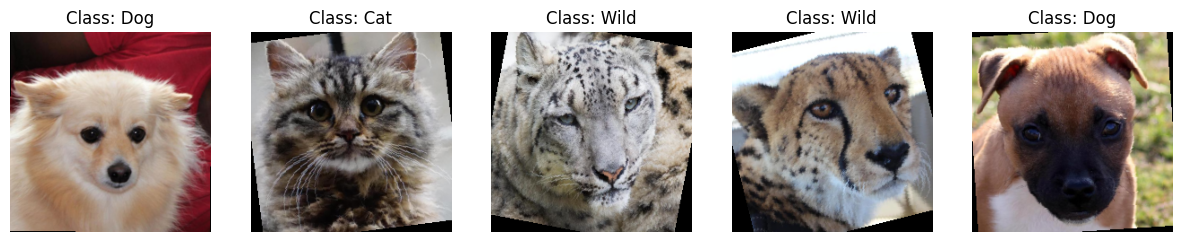

In [ ]:
def show_preprocessed_images(loader, n=5):
    #один батч данных
    images, labels = next(iter(loader))
    classes = ['Cat', 'Dog', 'Wild']

    plt.figure(figsize=(15, 5))
    for i in range(n):
        plt.subplot(1, n, i+1)
        img = images[i].permute(1, 2, 0).numpy()

        img = np.clip(img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406], 0, 1)

        plt.imshow(img)
        plt.title(f"Class: {classes[labels[i]]}")
        plt.axis('off')
    plt.show()

show_preprocessed_images(train_loader)

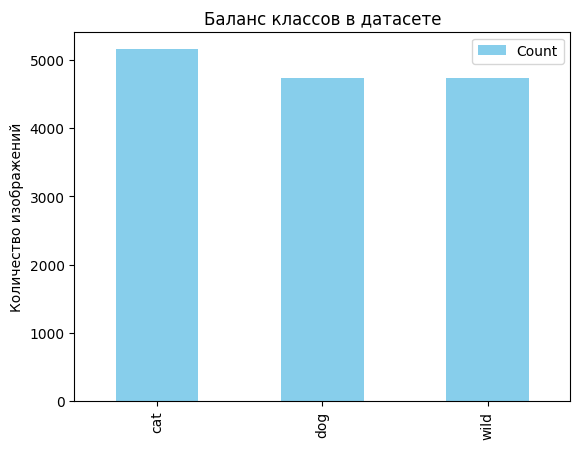

{'cat': 5153, 'dog': 4739, 'wild': 4738}


In [ ]:
def check_balance(dataset):
    counts = {}
    for i, class_name in enumerate(dataset.classes):
        count = len([x for x in dataset.samples if x[1] == i])
        counts[class_name] = count

    df = pd.DataFrame.from_dict(counts, orient='index', columns=['Count'])
    df.plot(kind='bar', color='skyblue')
    plt.title("Баланс классов в датасете")
    plt.ylabel("Количество изображений")
    plt.show()
    print(counts)

check_balance(train_ds)

In [ ]:
train_ds = datasets.ImageFolder(train_path, transform=train_transform)
val_ds = datasets.ImageFolder(val_path, transform=val_transform)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=64, num_workers=2)

In [ ]:

# модель (Lightning)
class AnimalModel(pl.LightningModule):
    def __init__(self):
        super().__init__()
        self.model = models.resnet50(weights='DEFAULT')
        self.model.fc = nn.Linear(self.model.fc.in_features, 3)
        self.accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=3)
        self.criterion = nn.CrossEntropyLoss()

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        self.log('train_loss', loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        acc = self.accuracy(logits, y)
        self.log_dict({'val_loss': loss, 'val_acc': acc}, prog_bar=True)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=1e-4)


In [ ]:
model = AnimalModel()
trainer = pl.Trainer(
    max_epochs=3,
    accelerator="gpu",
    devices=1,
    precision="16-mixed")

trainer.fit(model, train_loader, val_loader)

#метрики на валидации
trainer.validate(model, val_loader)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 164MB/s]
INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/model_summary/model_sum

┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ ResNet             │ 23.5 M │ train │     0 │
│ 1 │ accuracy  │ MulticlassAccuracy │      0 │ train │     0 │
│ 2 │ criterion │ CrossEntropyLoss   │      0 │ train │     0 │
└───┴───────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 23.5 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 23.5 M                                                                                               
Total estimated model params size (MB): 94                                                                         
Modules in train mode: 153                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=3` reached.


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│          val_acc          │    0.9926666617393494     │
│         val_loss          │   0.024398857727646828    │
└───────────────────────────┴───────────────────────────┘

[{'val_loss': 0.024398857727646828, 'val_acc': 0.9926666617393494}]


Отчет по классам
              precision    recall  f1-score   support

         Cat       1.00      1.00      1.00       500
         Dog       0.98      1.00      0.99       500
        Wild       1.00      0.98      0.99       500

    accuracy                           0.99      1500
   macro avg       0.99      0.99      0.99      1500
weighted avg       0.99      0.99      0.99      1500



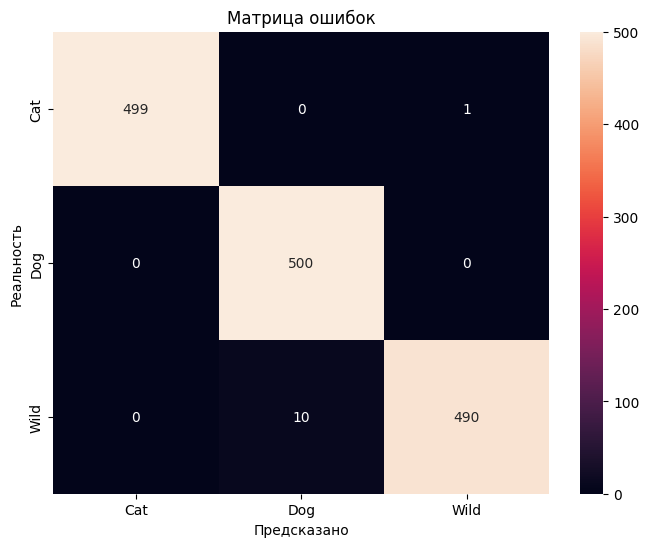

In [ ]:
#отчет
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in val_loader:
        logits = model(images.to(model.device))
        preds = torch.argmax(logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

classes = ['Cat', 'Dog', 'Wild']

print("\n""Отчет по классам")
print(classification_report(y_true, y_pred, target_names=classes))

#мартица ошибок
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes)
plt.xlabel('Предсказано')
plt.ylabel('Реальность')
plt.title('Матрица ошибок')
plt.show()

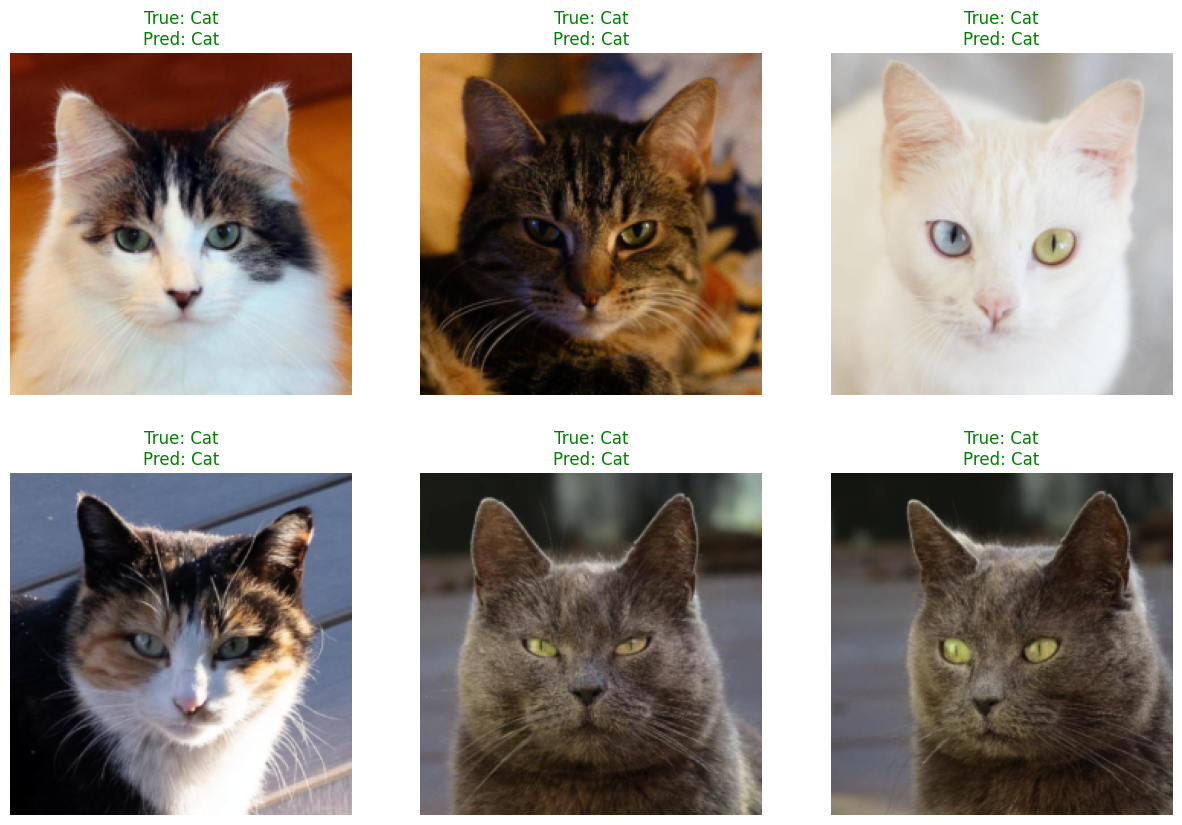

In [ ]:
#визуализация
def plot_predictions(model, loader):
    model.eval()
    images, labels = next(iter(loader))
    classes = ['Cat', 'Dog', 'Wild']

    with torch.no_grad():
        logits = model(images.to(model.device))
        preds = torch.argmax(logits, dim=1)

    plt.figure(figsize=(15, 10))
    for i in range(6):
        plt.subplot(2, 3, i+1)
        img = images[i].permute(1, 2, 0).cpu().numpy()
        img = np.clip(img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406], 0, 1)

        is_correct = preds[i] == labels[i]
        title_color = 'green' if is_correct else 'red'

        plt.imshow(img)
        plt.title(f"True: {classes[labels[i]]}\nPred: {classes[preds[i]]}", color=title_color)
        plt.axis('off')
    plt.show()

plot_predictions(model, val_loader)

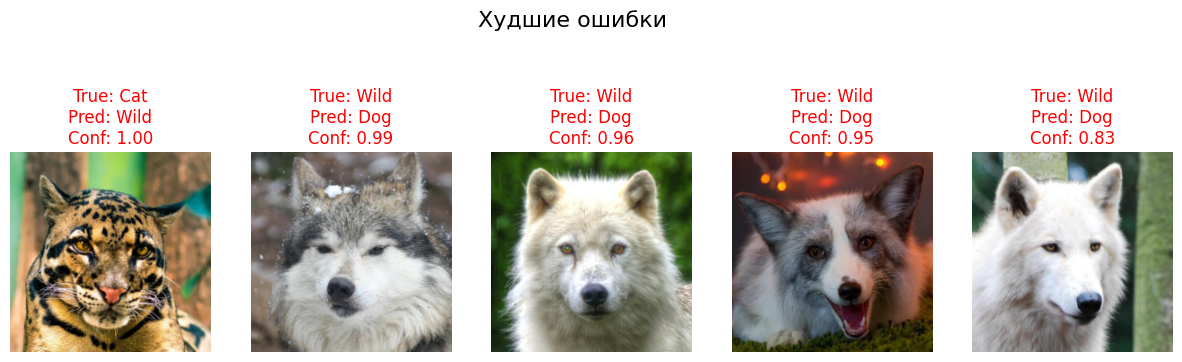

In [ ]:
model.eval()
errors = []

#посмотрим на ошибки
with torch.no_grad():
    for images, labels in val_loader:
        logits = model(images.to(model.device))
        probs = F.softmax(logits, dim=1)
        preds = torch.argmax(logits, dim=1)

        #только ошибки
        wrong_mask = (preds != labels.to(model.device))
        wrong_idx = wrong_mask.nonzero(as_tuple=True)[0]

        for idx in wrong_idx:
            errors.append({
                'image': images[idx],
                'true': labels[idx].item(),
                'pred': preds[idx].item(),
                'conf': probs[idx][preds[idx]].item()
            })
errors = sorted(errors, key=lambda x: x['conf'], reverse=True)

#визуализация
classes = ['Cat', 'Dog', 'Wild']
plt.figure(figsize=(15, 5))
num_show = min(len(errors), 5)

if num_show > 0:
    for i in range(num_show):
        plt.subplot(1, num_show, i+1)
        img = errors[i]['image'].permute(1, 2, 0).cpu().numpy()
        img = np.clip(img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406], 0, 1)
        plt.imshow(img)
        plt.title(f"True: {classes[errors[i]['true']]}\nPred: {classes[errors[i]['pred']]}\nConf: {errors[i]['conf']:.2f}", color='red')
        plt.axis('off')
    plt.suptitle("Худшие ошибки", fontsize=16)
    plt.show()

Использование предобученной архитектуры ResNet50 с применением Transfer Learning позволило достичь высокой точности всего за 3 эпохи обучения.
Точность модели (Accuracy) составила 99%. Модель идеально классифицирует кошек. Небольшая погрешность наблюдается только в различении собак и диких животных (recall для wild 0.98), что объясняется визуальной схожестью некоторых видов (например, волков и собак).
В ходе анализа ошибок была обнаружена ошибка разметки  в исходном датасете: дикое животное было ошибочно классифицировано как домашнее. Поскольку точность модели составляет 99%, данный шум не повлиял на общую обобщающую способность, но если ошибка будет более 2-3%, нужно провести санацию данных для этого класса